<a href="https://colab.research.google.com/github/RuiRodrigues-lab/DataScienceFE/blob/Locker/CP4_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
#Precisamos desta biblioteca para podermos escolher um ficheiro local
#Se o ficheiro vier por API ou tivermos um link, é so alterar a forma de import
from google.colab import files

# 1️⃣ Faz upload do ficheiro (vai abrir uma janela para escolher no teu PC)
uploaded = files.upload()

# 2️⃣ Guarda o nome do ficheiro (Colab mostra o nome depois do upload)
filename = list(uploaded.keys())[0]

# 3️⃣ Lê o Excel, por default lê sempre a primeira tab, por isso podemos usar o "sheet_name"
# Se tivermos dados em varias tabs, devemos usar uma Dataframe(df) para cada uma das tabs
df = pd.read_excel(filename, sheet_name='Exerc5')
df.head()

Saving CP4_5.xlsx to CP4_5 (1).xlsx


,Produtividade,Tempo
0,15,10
1,12,5
2,14,7
3,18,12
4,13,4


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Produtividade  20 non-null     int64
 1   Tempo          20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


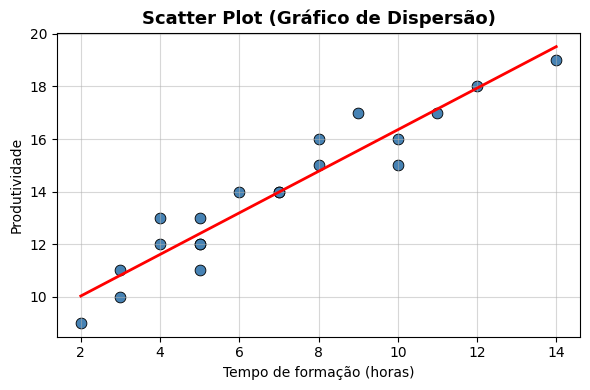

Coeficiente angular (b1): 0.79
Intercepto (b0): 8.44
Correlação de Pearson:  0.953002
Correlação de Spearman: 0.952128


In [7]:
# 🔹 Gráfico de dispersão (equivalente a plot())
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x="Tempo", y="Produtividade",
    data=df, color="steelblue", s=60, edgecolor="black"
)

# 🔹 Regressão linear (equivalente a lm() + abline())
X = df[["Tempo"]]
y = df["Produtividade"]

model = LinearRegression()
model.fit(X, y)

# Gerar valores previstos
x_vals = np.linspace(df["Tempo"].min(), df["Tempo"].max(), 100)
y_vals = model.predict(x_vals.reshape(-1, 1))

plt.plot(x_vals, y_vals, color="red", linewidth=2)

# 🔹 Melhorar o gráfico
plt.title("Scatter Plot (Gráfico de Dispersão)", fontsize=13, weight="bold")
plt.xlabel("Tempo de formação (horas)")
plt.ylabel("Produtividade")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

# 🔹 Coeficientes (opcional)
print(f"Coeficiente angular (b1): {model.coef_[0]:.2f}")
print(f"Intercepto (b0): {model.intercept_:.2f}")

# 🔹 Correlação de Pearson (linear)
cor_pearson = df["Produtividade"].corr(df["Tempo"], method="pearson")

# 🔹 Correlação de Spearman (por postos)
cor_spearman = df["Produtividade"].corr(df["Tempo"], method="spearman")

print(f"Correlação de Pearson:  {cor_pearson:.6f}")
print(f"Correlação de Spearman: {cor_spearman:.6f}")